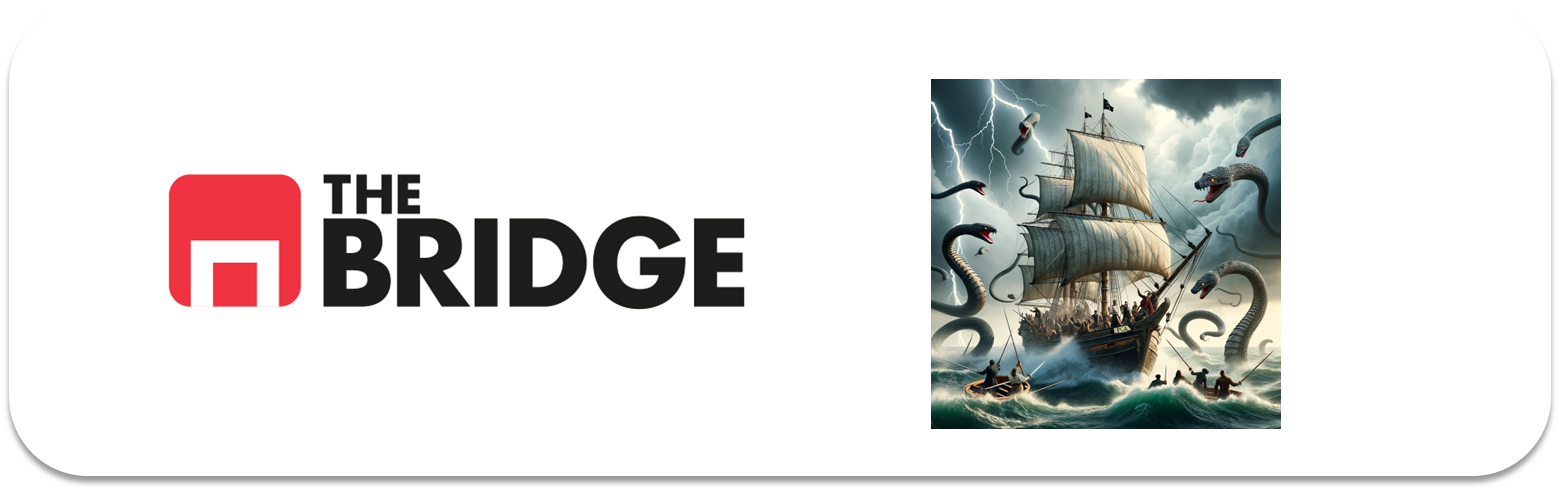

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, balanced_accuracy_score

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




### 1.1 Carga e inspección inicial del dataset

Cargamos el dataset Olivetti Faces y comprobamos las dimensiones de las imágenes y de los datos que utilizaremos para construir el modelo.

In [4]:
olivetti = fetch_olivetti_faces()

In [5]:
olivetti.images.shape

(400, 64, 64)

In [6]:
olivetti.data.shape

(400, 4096)

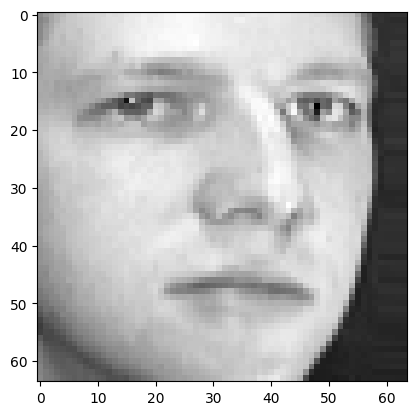

In [7]:
plt.imshow(olivetti.data[4].reshape(64, 64), cmap="gray")
plt.show()

### 1.2 Construcción del DataFrame

Construimos un DataFrame con los datos de las imágenes, donde cada píxel representa una feature, y añadimos el identificador de la persona como variable objetivo.

In [8]:
df = pd.DataFrame(
    olivetti.data,
    columns=[f"pixel_{i}" for i in range(olivetti.data.shape[1])]
)

df["face_id"] = olivetti.target

df.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095,face_id
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025,0
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893,0
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893,0
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669,0
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554,0


In [9]:
df.shape

(400, 4097)

In [10]:
df["face_id"].value_counts().sort_index()

face_id
0     10
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8     10
9     10
10    10
11    10
12    10
13    10
14    10
15    10
16    10
17    10
18    10
19    10
20    10
21    10
22    10
23    10
24    10
25    10
26    10
27    10
28    10
29    10
30    10
31    10
32    10
33    10
34    10
35    10
36    10
37    10
38    10
39    10
Name: count, dtype: int64

### 1.3 División en Train y Test

Separamos las variables predictoras del target y realizamos un split estratificado, reservando el 20 % de los datos para test. De esta forma obtenemos 80 imágenes en test y mantenemos la representación de las 40 personas en ambos conjuntos.

In [11]:
X = df.drop(columns="face_id")
y = df["face_id"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (320, 4096)
X_test: (80, 4096)
y_train: (320,)
y_test: (80,)


### 1.4 Quick MiniEDA

Realizamos una comprobación básica de la calidad de los datos. Al tratarse de imágenes, las 4096 variables predictoras representan intensidades de píxeles, por lo que no resulta útil realizar un análisis univariante o bivariante tradicional sobre cada una de ellas.

In [14]:
print("Valores nulos:", X_train.isna().sum().sum())
print("Valores duplicados:", X_train.duplicated().sum())
print("Rango de valores:", X_train.min().min(), "-", X_train.max().max())

Valores nulos: 0
Valores duplicados: 0
Rango de valores: 0.0 - 1.0


In [15]:
print("Imágenes por persona en Train:")
print(y_train.value_counts().sort_index())

print("\nImágenes por persona en Test:")
print(y_test.value_counts().sort_index())

Imágenes por persona en Train:
face_id
0     8
1     8
2     8
3     8
4     8
5     8
6     8
7     8
8     8
9     8
10    8
11    8
12    8
13    8
14    8
15    8
16    8
17    8
18    8
19    8
20    8
21    8
22    8
23    8
24    8
25    8
26    8
27    8
28    8
29    8
30    8
31    8
32    8
33    8
34    8
35    8
36    8
37    8
38    8
39    8
Name: count, dtype: int64

Imágenes por persona en Test:
face_id
0     2
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     2
9     2
10    2
11    2
12    2
13    2
14    2
15    2
16    2
17    2
18    2
19    2
20    2
21    2
22    2
23    2
24    2
25    2
26    2
27    2
28    2
29    2
30    2
31    2
32    2
33    2
34    2
35    2
36    2
37    2
38    2
39    2
Name: count, dtype: int64


#### Importancia de los píxeles

Como las features representan píxeles individuales, analizamos visualmente la importancia asignada por el Random Forest para comprobar si existen zonas de la imagen claramente más relevantes para la clasificación.

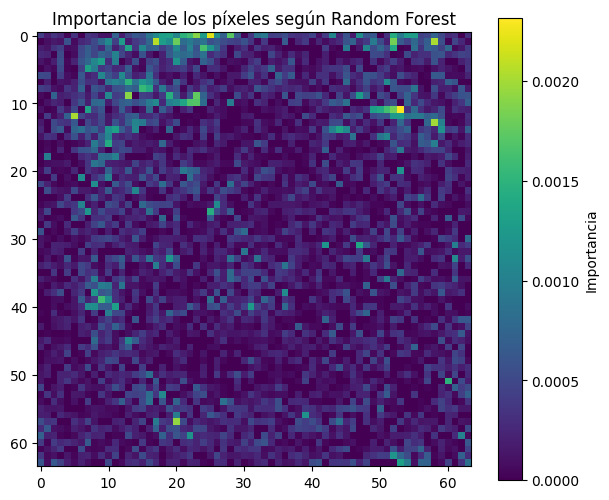

In [22]:
imagen_importancia = rf_clf_importancia.feature_importances_.reshape(64, 64)

plt.figure(figsize=(7, 6))
plt.imshow(imagen_importancia)
plt.colorbar(label="Importancia")
plt.title("Importancia de los píxeles según Random Forest")
plt.show()

In [23]:
pd.Series(rf_clf_importancia.feature_importances_).describe()

count    4096.000000
mean        0.000244
std         0.000280
min         0.000000
25%         0.000032
50%         0.000172
75%         0.000353
max         0.002314
dtype: float64

**Conclusión:** La importancia se encuentra distribuida entre un gran número de píxeles. Aunque algunos presentan una mayor relevancia, la importancia individual es reducida y ningún píxel destaca claramente sobre el conjunto. Por tanto, no parece conveniente realizar una selección directa de píxeles, lo que refuerza el interés de utilizar PCA para reducir la dimensionalidad combinando la información de las features originales.

#### Conclusión del MiniEDA

El conjunto de entrenamiento no presenta valores nulos ni registros duplicados. Los valores de los píxeles se encuentran en un rango entre 0 y 1.

Además, gracias al split estratificado, las 40 personas están representadas de forma equilibrada en ambos conjuntos, con 8 imágenes por persona en Train y 2 en Test.

Dado que las 4096 variables predictoras corresponden directamente a los píxeles de las imágenes, no se considera necesario realizar un análisis univariante o bivariante tradicional de cada feature.

#### 1.4.2 Análisis del rango de los píxeles

Analizamos el rango de las features para comprobar si existen diferencias importantes entre las escalas de los píxeles y valorar si sería necesario realizar un escalado antes de aplicar PCA.

In [24]:
df_describe = X_train.describe().T

df_describe["rango"] = df_describe["max"] - df_describe["min"]

df_describe["rango"].describe()

count    4096.000000
mean        0.690177
std         0.097665
min         0.396694
25%         0.636364
50%         0.702479
75%         0.756198
max         0.946281
Name: rango, dtype: float64

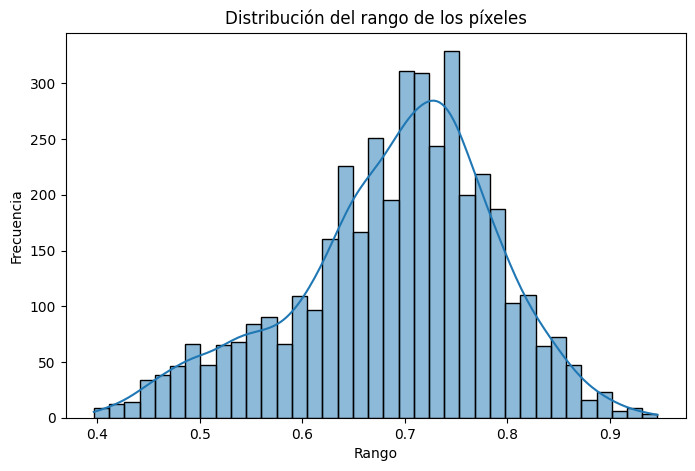

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(df_describe["rango"], kde=True)

plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.title("Distribución del rango de los píxeles")

plt.show()

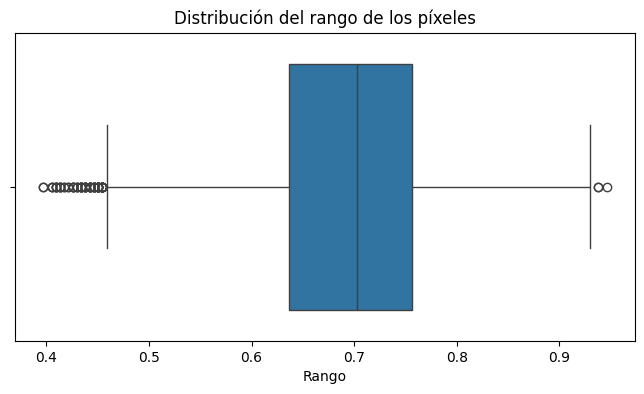

In [26]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df_describe["rango"])

plt.xlabel("Rango")
plt.title("Distribución del rango de los píxeles")

plt.show()

**Conclusión:** Los píxeles se encuentran originalmente en la misma escala (0-1) y sus rangos presentan una distribución relativamente homogénea, concentrándose la mayoría alrededor de valores similares. Aunque existen algunos valores atípicos, no se observan diferencias de escala suficientemente importantes entre las features que justifiquen un escalado adicional. Por tanto, se trabajará con los valores originales antes de aplicar PCA.

### 1.5 Modelo baseline

Construimos un modelo Random Forest utilizando las 4096 features originales. Este modelo servirá como referencia para comparar posteriormente el rendimiento de los modelos que utilicen imágenes comprimidas mediante PCA.

In [16]:
rf_clf_importancia = RandomForestClassifier(random_state=42)

rf_clf_importancia.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
y_pred = rf_clf_importancia.predict(X_test)

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      0.50      0.67         2
          16       1.00      1.00      1.00         2
          17       0.67    

In [19]:
baseline_test = recall_score(y_test, y_pred, average="macro")

baseline_test

0.95

### 1.6 Evaluación del baseline mediante Cross Validation

Evaluamos el modelo baseline mediante validación cruzada con 5 folds utilizando `balanced_accuracy` como métrica. Guardamos la media obtenida para utilizarla posteriormente como referencia al evaluar los modelos con PCA.

In [20]:
cv_scores = cross_val_score(
    rf_clf_importancia,
    X_train,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

cv_scores

array([0.9875, 0.9375, 0.95  , 0.9   , 0.9   ])

In [21]:
baseline_cv = cv_scores.mean()

baseline_cv

np.float64(0.9349999999999999)

### Conclusión del modelo baseline

El modelo Random Forest utilizando las 4096 features originales obtiene un `balanced_accuracy` medio de 0.935 mediante validación cruzada y un recall macro de 0.95 sobre el conjunto de test.

Estos resultados se tomarán como referencia para evaluar posteriormente cuánto podemos reducir el tamaño de las imágenes mediante PCA sin provocar una pérdida significativa en la capacidad de clasificación del modelo.

### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

### 2.1 PCA sobre los datos de entrenamiento

Instanciamos PCA sin limitar inicialmente el número de componentes y lo ajustamos únicamente sobre el conjunto de entrenamiento. De esta forma podremos analizar cuántas componentes principales están disponibles antes de decidir los niveles de compresión que queremos probar.

In [27]:
pca = PCA()

pca.fit(X_train)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [29]:
print("Dimensiones de X_train:", X_train.shape)
print("Número de componentes PCA:", pca.n_components_)

Dimensiones de X_train: (320, 4096)
Número de componentes PCA: 320


### 2.2 Selección del número de componentes principales

Cada imagen original está representada por 4096 píxeles. Para obtener imágenes comprimidas entre aproximadamente el 0.2 % y el 2.5 % de su tamaño original, debemos probar números de componentes PCA comprendidos aproximadamente entre 9 y 102.

Seleccionamos varios valores dentro de este intervalo para estudiar cómo afecta el nivel de compresión al rendimiento del modelo.

In [30]:
n_features = X_train.shape[1]

min_componentes = int(np.ceil(n_features * 0.002))
max_componentes = int(np.floor(n_features * 0.025))

print("Número mínimo de componentes:", min_componentes)
print("Número máximo de componentes:", max_componentes)

Número mínimo de componentes: 9
Número máximo de componentes: 102


In [31]:
componentes = [10, 20, 30, 40, 50, 60, 80, 100]

for n in componentes:
    porcentaje = n / n_features * 100
    print(f"{n} componentes -> {porcentaje:.2f}% del tamaño original")

10 componentes -> 0.24% del tamaño original
20 componentes -> 0.49% del tamaño original
30 componentes -> 0.73% del tamaño original
40 componentes -> 0.98% del tamaño original
50 componentes -> 1.22% del tamaño original
60 componentes -> 1.46% del tamaño original
80 componentes -> 1.95% del tamaño original
100 componentes -> 2.44% del tamaño original


**Conclusión:** El rango seleccionado permite evaluar distintos niveles de compresión, desde conservar aproximadamente un 0.24 % hasta un 2.44 % del tamaño original de las imágenes. De esta forma podremos analizar cuánto podemos reducir la dimensionalidad manteniendo un rendimiento de clasificación cercano al modelo baseline.

### 2.3 Evaluación del modelo con distintos niveles de compresión

Para cada número de componentes seleccionado aplicamos PCA sobre los datos de entrenamiento y transformamos posteriormente el conjunto de test. A continuación, entrenamos un Random Forest y evaluamos su rendimiento mediante validación cruzada con 5 folds y recall medio sobre test.

Los resultados se almacenan para poder compararlos posteriormente con el modelo baseline.

In [32]:
resultados = []

In [33]:
for n in componentes:

    # Aplicamos PCA
    pca_n = PCA(n_components=n)
    X_train_pca = pca_n.fit_transform(X_train)
    X_test_pca = pca_n.transform(X_test)

    # Modelo de clasificación
    modelo = RandomForestClassifier(random_state=42)

    # Cross Validation
    cv_scores_pca = cross_val_score(
        modelo,
        X_train_pca,
        y_train,
        cv=5,
        scoring="balanced_accuracy"
    )

    score_cv = cv_scores_pca.mean()

    # Entrenamiento y evaluación sobre Test
    modelo.fit(X_train_pca, y_train)
    y_pred_pca = modelo.predict(X_test_pca)

    score_test = recall_score(
        y_test,
        y_pred_pca,
        average="macro"
    )

    # Guardamos resultados
    resultados.append({
        "n_componentes": n,
        "score_cv": score_cv,
        "score_test": score_test
    })

In [34]:
resultados

[{'n_componentes': 10,
  'score_cv': np.float64(0.8524999999999998),
  'score_test': 0.775},
 {'n_componentes': 20, 'score_cv': np.float64(0.89), 'score_test': 0.9125},
 {'n_componentes': 30, 'score_cv': np.float64(0.9075), 'score_test': 0.9125},
 {'n_componentes': 40, 'score_cv': np.float64(0.915), 'score_test': 0.9375},
 {'n_componentes': 50,
  'score_cv': np.float64(0.9199999999999999),
  'score_test': 0.925},
 {'n_componentes': 60,
  'score_cv': np.float64(0.9199999999999999),
  'score_test': 0.9},
 {'n_componentes': 80,
  'score_cv': np.float64(0.9024999999999999),
  'score_test': 0.925},
 {'n_componentes': 100, 'score_cv': np.float64(0.885), 'score_test': 0.9375}]

### 2.4 Comparación de resultados con el modelo baseline

Organizamos los resultados obtenidos para cada número de componentes principales y calculamos el porcentaje del tamaño original que representa cada compresión. Además, comparamos los resultados de validación cruzada y test con los obtenidos por el modelo baseline.

In [35]:
df_resultados = pd.DataFrame(resultados)

df_resultados

,n_componentes,score_cv,score_test
0,10,0.8525,0.7750
1,20,0.8900,0.9125
2,30,0.9075,0.9125
3,40,0.9150,0.9375
4,50,0.9200,0.9250
5,60,0.9200,0.9000
6,80,0.9025,0.9250
7,100,0.8850,0.9375


In [36]:
df_resultados["compresion_%"] = (
    df_resultados["n_componentes"] / n_features * 100
)

In [37]:
df_resultados["diferencia_cv"] = (
    df_resultados["score_cv"] - baseline_cv
)

df_resultados["diferencia_test"] = (
    df_resultados["score_test"] - baseline_test
)

In [38]:
df_resultados = df_resultados.round(4)

df_resultados

,n_componentes,score_cv,score_test,compresion_%,diferencia_cv,diferencia_test
0,10,0.8525,0.7750,0.2441,-0.0825,-0.1750
1,20,0.8900,0.9125,0.4883,-0.0450,-0.0375
2,30,0.9075,0.9125,0.7324,-0.0275,-0.0375
3,40,0.9150,0.9375,0.9766,-0.0200,-0.0125
4,50,0.9200,0.9250,1.2207,-0.0150,-0.0250
5,60,0.9200,0.9000,1.4648,-0.0150,-0.0500
6,80,0.9025,0.9250,1.9531,-0.0325,-0.0250
7,100,0.8850,0.9375,2.4414,-0.0500,-0.0125


#### 2.4.1 Comparación gráfica con el baseline

Representamos el rendimiento obtenido con cada número de componentes y lo comparamos con los resultados del modelo baseline para visualizar el efecto de la compresión sobre la capacidad de clasificación.

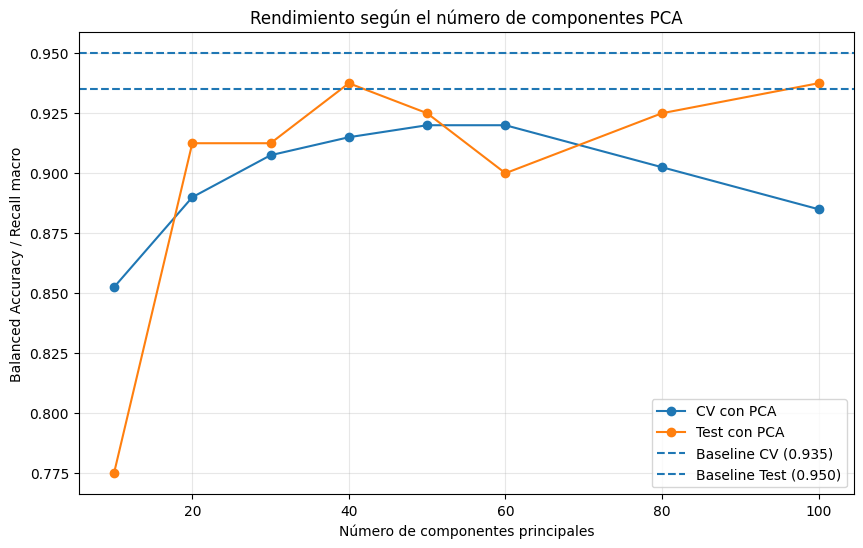

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(
    df_resultados["n_componentes"],
    df_resultados["score_cv"],
    marker="o",
    label="CV con PCA"
)

plt.plot(
    df_resultados["n_componentes"],
    df_resultados["score_test"],
    marker="o",
    label="Test con PCA"
)

plt.axhline(
    baseline_cv,
    linestyle="--",
    label=f"Baseline CV ({baseline_cv:.3f})"
)

plt.axhline(
    baseline_test,
    linestyle="--",
    label=f"Baseline Test ({baseline_test:.3f})"
)

plt.xlabel("Número de componentes principales")
plt.ylabel("Balanced Accuracy / Recall macro")
plt.title("Rendimiento según el número de componentes PCA")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Conclusión:** La reducción mediante PCA permite mantener un rendimiento cercano al modelo baseline utilizando una fracción muy pequeña de las features originales. Los resultados muestran que aumentar el número de componentes no implica necesariamente una mejora continua del rendimiento.

Entre los valores evaluados, 40 componentes destacan por mantener una pérdida inferior a 3 puntos porcentuales tanto en validación cruzada como en test, representando aproximadamente el 0.98 % del tamaño original de la imagen. La selección definitiva se realizará aplicando formalmente el criterio establecido en el siguiente apartado.

### 2.5 Selección del número de componentes

Seleccionamos el menor número de componentes que mantenga una pérdida inferior a 3 puntos porcentuales respecto al modelo baseline tanto en validación cruzada como en test. Al conservar menos componentes se obtiene una mayor compresión de las imágenes.

In [40]:
candidatos_3 = df_resultados[
    (df_resultados["diferencia_cv"] > -0.03) &
    (df_resultados["diferencia_test"] > -0.03)
]

candidatos_3

,n_componentes,score_cv,score_test,compresion_%,diferencia_cv,diferencia_test
3,40,0.915,0.9375,0.9766,-0.020,-0.0125
4,50,0.920,0.9250,1.2207,-0.015,-0.0250


In [41]:
mejor_opcion = candidatos_3.sort_values("n_componentes").iloc[0]

mejor_opcion

n_componentes      40.0000
score_cv            0.9150
score_test          0.9375
compresion_%        0.9766
diferencia_cv      -0.0200
diferencia_test    -0.0125
Name: 3, dtype: float64

**Conclusión:** De las configuraciones evaluadas, los modelos con 40 y 50 componentes cumplen el criterio establecido de mantener una pérdida inferior a 3 puntos porcentuales respecto al baseline tanto en validación cruzada como en test.

Entre ambas opciones se seleccionan **40 componentes**, ya que es la configuración que proporciona la mayor compresión. Con ella, cada imagen pasa de 4096 variables originales a solo 40 componentes, conservando aproximadamente el **0.98 % del tamaño original**.

El modelo obtiene un `balanced_accuracy` de **0.915 en validación cruzada**, frente al 0.935 del baseline, lo que supone una pérdida de **2 puntos porcentuales**. En test obtiene **0.9375**, frente al 0.95 del baseline, con una pérdida de solo **1.25 puntos porcentuales**.

Por tanto, 40 componentes permiten reducir considerablemente la cantidad de datos necesaria para representar cada imagen manteniendo un rendimiento de clasificación muy próximo al modelo que utiliza todos los píxeles originales.

### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

### 3.1 Selección del rango de componentes PCA

Para simular una situación con un ancho de banda todavía más limitado, buscamos representar cada imagen utilizando entre el 0.1 % y el 1 % de su tamaño original.

Partiendo de las 4096 features originales, este intervalo corresponde aproximadamente a un rango de entre 5 y 40 componentes principales. Seleccionamos 5 valores dentro de este intervalo para evaluar distintos niveles de compresión.

In [42]:
min_componentes_3 = int(np.ceil(n_features * 0.001))
max_componentes_3 = int(np.floor(n_features * 0.01))

print("Número mínimo de componentes:", min_componentes_3)
print("Número máximo de componentes:", max_componentes_3)

Número mínimo de componentes: 5
Número máximo de componentes: 40


In [43]:
componentes_3 = [5, 10, 20, 30, 40]

In [44]:
for n in componentes_3:
    porcentaje = n / n_features * 100
    print(f"{n} componentes -> {porcentaje:.2f}% del tamaño original")

5 componentes -> 0.12% del tamaño original
10 componentes -> 0.24% del tamaño original
20 componentes -> 0.49% del tamaño original
30 componentes -> 0.73% del tamaño original
40 componentes -> 0.98% del tamaño original


### 3.2 Compresión, reconstrucción y evaluación del modelo

Para cada número de componentes seleccionado, aplicamos PCA sobre el conjunto de entrenamiento para comprimir las imágenes. Posteriormente utilizamos `inverse_transform` para reconstruirlas en el espacio original de 4096 píxeles.

El modelo de clasificación se entrena sobre las imágenes reconstruidas y se evalúa sobre el conjunto de test reconstruido de la misma forma. Utilizamos `balanced_accuracy` para comparar posteriormente su rendimiento con el modelo baseline.

In [45]:
resultados_3 = []

for n in componentes_3:

    # PCA
    pca_n = PCA(n_components=n)

    # Comprimimos Train y Test
    X_train_zipped = pca_n.fit_transform(X_train)
    X_test_zipped = pca_n.transform(X_test)

    # Reconstruimos las imágenes
    X_train_unzipped = pca_n.inverse_transform(X_train_zipped)
    X_test_unzipped = pca_n.inverse_transform(X_test_zipped)

    # Entrenamos el modelo con las imágenes reconstruidas
    modelo = RandomForestClassifier(random_state=42)
    modelo.fit(X_train_unzipped, y_train)

    # Predicción sobre Test reconstruido
    y_pred_unzipped = modelo.predict(X_test_unzipped)

    # Balanced Accuracy
    score_test = balanced_accuracy_score(
        y_test,
        y_pred_unzipped
    )

    # Guardamos los resultados
    resultados_3.append({
        "n_componentes": n,
        "score_test": score_test
    })

In [46]:
resultados_3

[{'n_componentes': 5, 'score_test': 0.625},
 {'n_componentes': 10, 'score_test': 0.825},
 {'n_componentes': 20, 'score_test': 0.9125},
 {'n_componentes': 30, 'score_test': 0.925},
 {'n_componentes': 40, 'score_test': 0.9625}]

#### 3.2.1 Comparación visual de las imágenes reconstruidas

Visualizamos una misma imagen original y sus reconstrucciones utilizando diferentes números de componentes principales. Esto permite observar cómo afecta el nivel de compresión a la información visual recuperada mediante `inverse_transform`.

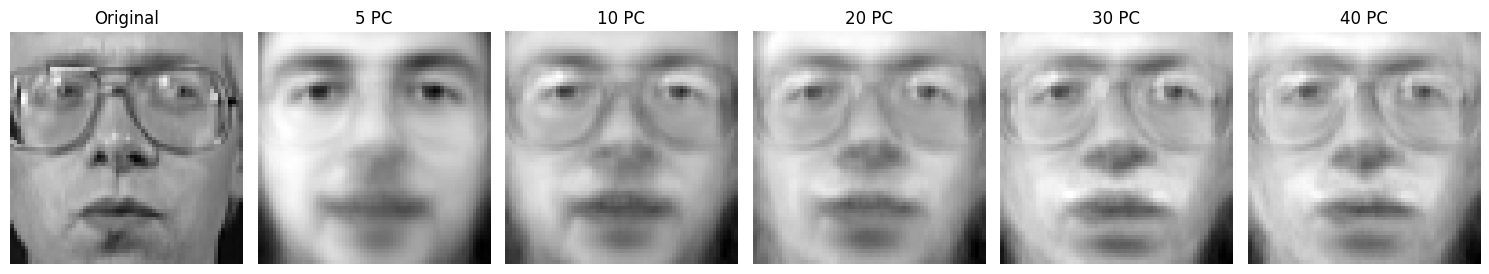

In [47]:
indice = 0

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

# Imagen original
axes[0].imshow(
    X_test.iloc[indice].values.reshape(64, 64),
    cmap="gray"
)
axes[0].set_title("Original")
axes[0].axis("off")

# Imágenes reconstruidas
for ax, n in zip(axes[1:], componentes_3):

    pca_visual = PCA(n_components=n)

    X_train_pca = pca_visual.fit_transform(X_train)
    X_test_pca = pca_visual.transform(X_test)

    X_test_reconstruido = pca_visual.inverse_transform(X_test_pca)

    ax.imshow(
        X_test_reconstruido[indice].reshape(64, 64),
        cmap="gray"
    )
    ax.set_title(f"{n} PC")
    ax.axis("off")

plt.tight_layout()
plt.show()

**Interpretación:** La reconstrucción mejora progresivamente al aumentar el número de componentes principales. Con muy pocas componentes se conservan los rasgos generales de la cara, pero se pierde una cantidad importante de detalle. A partir de 20-30 componentes la imagen recupera características más definidas, mientras que con 40 componentes se obtiene una reconstrucción suficientemente detallada pese a conservar menos del 1 % del tamaño original.

Esta mejora visual también se refleja en el rendimiento del clasificador, cuyo `balanced_accuracy` aumenta a medida que las imágenes reconstruidas contienen mayor información.

### 3.3 Comparación del rendimiento y nivel de compresión

Organizamos los resultados obtenidos para analizar conjuntamente el rendimiento del clasificador y el nivel de compresión alcanzado con cada número de componentes principales.

Además del `balanced_accuracy`, calculamos el porcentaje del tamaño original que representa cada imagen comprimida.

In [48]:
df_resultados_3 = pd.DataFrame(resultados_3)

df_resultados_3["compresion_%"] = (
    df_resultados_3["n_componentes"] / n_features * 100
)

df_resultados_3 = df_resultados_3.round(4)

df_resultados_3

,n_componentes,score_test,compresion_%
0,5,0.6250,0.1221
1,10,0.8250,0.2441
2,20,0.9125,0.4883
3,30,0.9250,0.7324
4,40,0.9625,0.9766


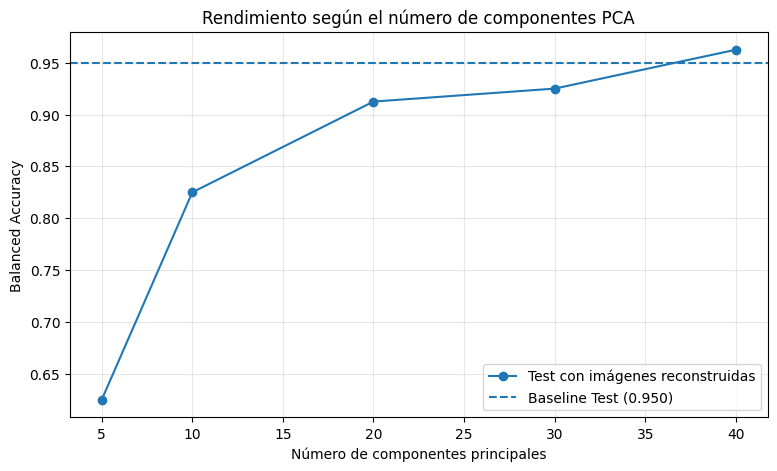

In [49]:
plt.figure(figsize=(9, 5))

plt.plot(
    df_resultados_3["n_componentes"],
    df_resultados_3["score_test"],
    marker="o",
    label="Test con imágenes reconstruidas"
)

plt.axhline(
    baseline_test,
    linestyle="--",
    label=f"Baseline Test ({baseline_test:.3f})"
)

plt.xlabel("Número de componentes principales")
plt.ylabel("Balanced Accuracy")
plt.title("Rendimiento según el número de componentes PCA")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [50]:
df_resultados_3["factor_compresion"] = (
    n_features / df_resultados_3["n_componentes"]
).round(2)

df_resultados_3

,n_componentes,score_test,compresion_%,factor_compresion
0,5,0.6250,0.1221,819.20
1,10,0.8250,0.2441,409.60
2,20,0.9125,0.4883,204.80
3,30,0.9250,0.7324,136.53
4,40,0.9625,0.9766,102.40


**Interpretación:** Se observa una mejora progresiva del `balanced_accuracy` al aumentar el número de componentes utilizados para reconstruir las imágenes. Los niveles de compresión más extremos, especialmente con 5 y 10 componentes, provocan una pérdida importante de rendimiento.

A partir de 20 componentes el rendimiento se aproxima considerablemente al baseline y con 40 componentes alcanza un `balanced_accuracy` de 0.9625, ligeramente superior al 0.95 obtenido con las imágenes originales. Esto se consigue representando inicialmente cada imagen con menos del 1 % de sus variables originales.

### 3.4 Selección del número de componentes

Para seleccionar la configuración final, buscamos la mayor compresión posible que mantenga una pérdida inferior a 3 puntos porcentuales respecto al `balanced_accuracy` del modelo baseline.

Dado que el baseline en test es 0.95, consideramos aceptables las configuraciones con un `balanced_accuracy` igual o superior a 0.92.

In [51]:
limite_3 = baseline_test - 0.03

candidatos_3_final = df_resultados_3[
    df_resultados_3["score_test"] >= limite_3
]

candidatos_3_final

,n_componentes,score_test,compresion_%,factor_compresion
3,30,0.9250,0.7324,136.53
4,40,0.9625,0.9766,102.40


In [52]:
mejor_opcion_3 = candidatos_3_final.sort_values(
    "n_componentes"
).iloc[0]

mejor_opcion_3

n_componentes         30.0000
score_test             0.9250
compresion_%           0.7324
factor_compresion    136.5300
Name: 3, dtype: float64

**Conclusión:** Las configuraciones con 30 y 40 componentes cumplen el requisito de mantener una pérdida inferior a 3 puntos porcentuales respecto al `balanced_accuracy` de 0.95 obtenido por el modelo baseline.

Se seleccionan **30 componentes**, ya que proporcionan la mayor compresión entre las configuraciones que cumplen este criterio. Con esta configuración, el modelo obtiene un `balanced_accuracy` de **0.925**, lo que supone una pérdida de **2.5 puntos porcentuales** respecto al baseline.

La imagen comprimida conserva únicamente el **0.73 % del tamaño original**, pasando de 4096 valores a 30 componentes y alcanzando un factor de compresión aproximado de **136.53 veces**.

Por tanto, esta configuración permite reducir de forma muy considerable la cantidad de información que deben transmitir las microcámaras y reconstruir posteriormente las imágenes en el servidor central, manteniendo el rendimiento del clasificador dentro del margen establecido.

### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

#### Extra 1.1 Obtención de las componentes principales

In [53]:
pca_extra = PCA(n_components=40)

X_train_pca_extra = pca_extra.fit_transform(X_train)

X_train_pca_extra.shape

(320, 40)

### Extra 1.2 Representación de las clases sobre las dos primeras componentes principales

Representamos las dos primeras componentes principales de la PCA seleccionada. Para facilitar la visualización de las 40 personas del dataset, dividimos las clases en cuatro grupos de 10 y mostramos cada grupo en un scatter plot independiente.

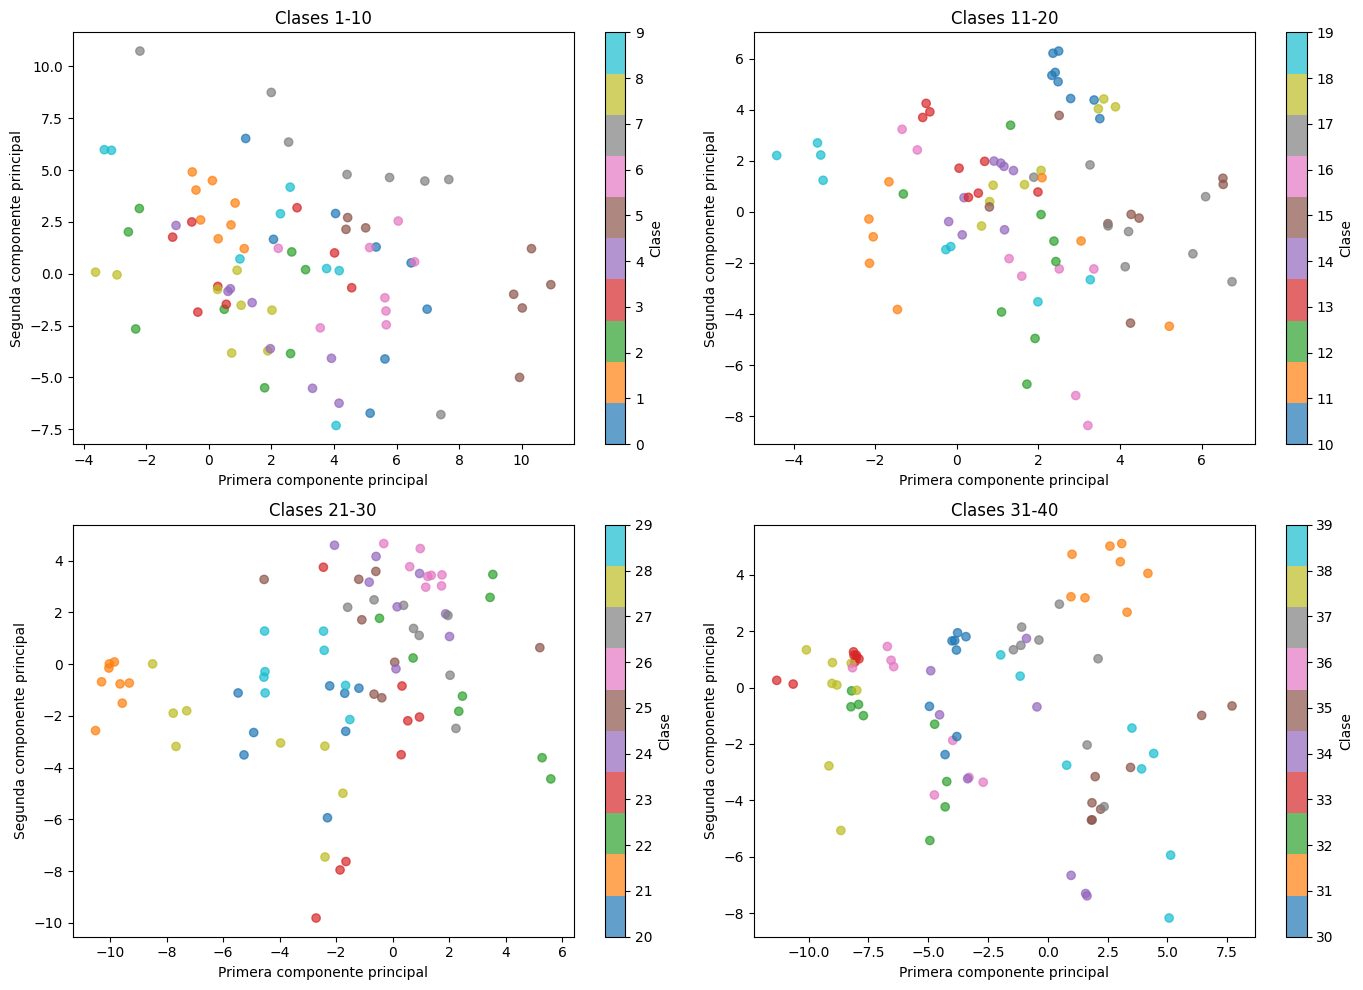

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

grupos = [
    range(0, 10),
    range(10, 20),
    range(20, 30),
    range(30, 40)
]

for ax, clases in zip(axes, grupos):

    mascara = y_train.isin(clases)

    scatter = ax.scatter(
        X_train_pca_extra[mascara, 0],
        X_train_pca_extra[mascara, 1],
        c=y_train[mascara],
        cmap="tab10",
        alpha=0.7
    )

    ax.set_xlabel("Primera componente principal")
    ax.set_ylabel("Segunda componente principal")
    ax.set_title(
        f"Clases {min(clases) + 1}-{max(clases) + 1}"
    )

    plt.colorbar(scatter, ax=ax, label="Clase")

plt.tight_layout()
plt.show()

### Conclusión del Extra 1

La representación mediante las dos primeras componentes principales permite observar cierta agrupación de las imágenes correspondientes a una misma persona, aunque existe un solapamiento considerable entre distintas clases.

Esto indica que las dos primeras componentes recogen parte de la información relevante de las imágenes, pero no son suficientes por sí solas para separar claramente las 40 personas. En el modelo de clasificación se utilizan 40 componentes principales, por lo que también se aprovecha la información contenida en componentes posteriores que no puede observarse en esta representación bidimensional.

### Extra 2. Reconstrucción y comparación visual de las imágenes

Creamos una función que permita comparar una imagen original con su reconstrucción después de aplicar PCA e `inverse_transform`.

Realizamos la comparación utilizando 5, 10, 20, 30, 40, 150 y 320 componentes principales para observar visualmente cómo afecta el nivel de compresión a la calidad de las imágenes reconstruidas.

In [56]:
componentes_extra = [5, 10, 20, 30, 40, 150, 320]

componentes_extra

[5, 10, 20, 30, 40, 150, 320]

In [57]:
for n in componentes_extra:
    porcentaje = n / n_features * 100
    print(f"{n} componentes -> {porcentaje:.2f}% del tamaño original")

5 componentes -> 0.12% del tamaño original
10 componentes -> 0.24% del tamaño original
20 componentes -> 0.49% del tamaño original
30 componentes -> 0.73% del tamaño original
40 componentes -> 0.98% del tamaño original
150 componentes -> 3.66% del tamaño original
320 componentes -> 7.81% del tamaño original


In [55]:
def visualizar_reconstruccion(X_train, X_test, n_componentes, n_caras=5):
    
    # Ajustamos PCA únicamente con Train
    pca = PCA(n_components=n_componentes)
    pca.fit(X_train)

    # Comprimimos y reconstruimos las imágenes de Test
    X_test_pca = pca.transform(X_test)
    X_test_reconstruido = pca.inverse_transform(X_test_pca)

    # Creamos la figura
    fig, axes = plt.subplots(
        2,
        n_caras,
        figsize=(3 * n_caras, 6)
    )

    for i in range(n_caras):

        # Imagen original
        axes[0, i].imshow(
            X_test.iloc[i].values.reshape(64, 64),
            cmap="gray"
        )
        axes[0, i].axis("off")

        # Imagen reconstruida
        axes[1, i].imshow(
            X_test_reconstruido[i].reshape(64, 64),
            cmap="gray"
        )
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel(
        f"{n_componentes} PC",
        fontsize=12
    )

    plt.suptitle(
        f"Reconstrucción de imágenes con {n_componentes} componentes principales",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

#### Extra 2.1 Comprobación de la reconstrucción con 5 componentes

Comprobamos el funcionamiento de la función visualizando cinco imágenes originales y sus correspondientes reconstrucciones utilizando 5 componentes principales.

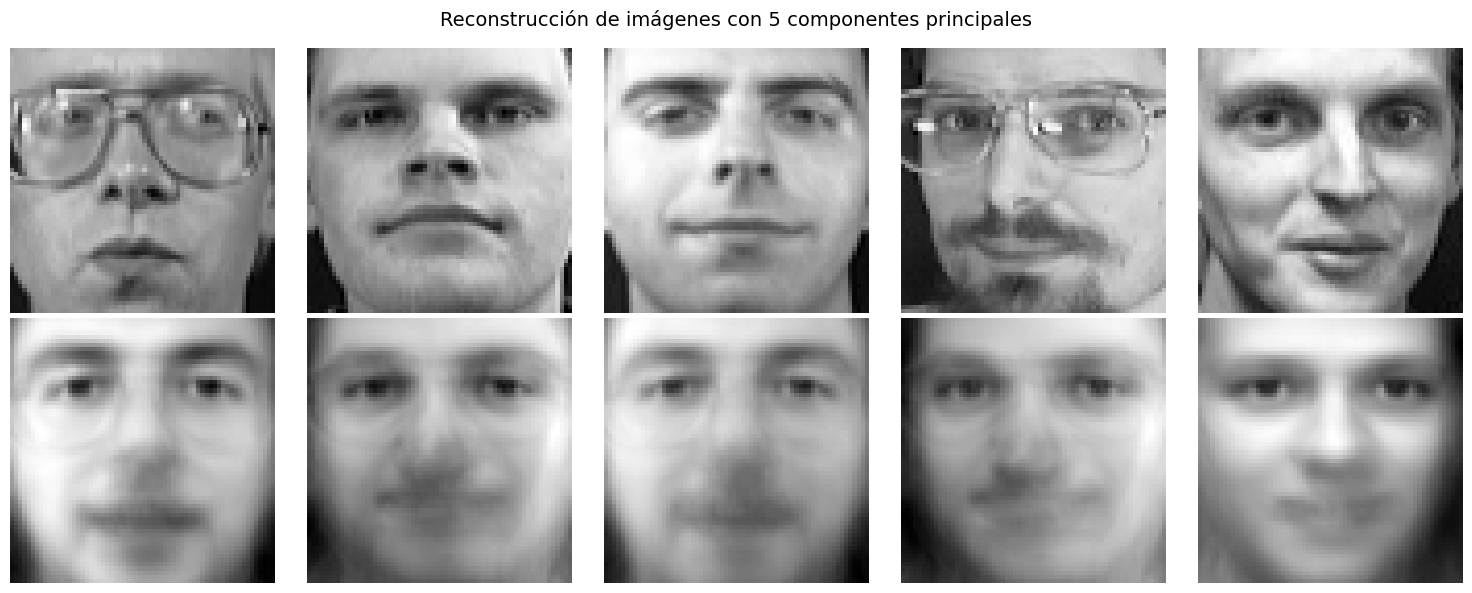

In [58]:
visualizar_reconstruccion(
    X_train,
    X_test,
    n_componentes=5,
    n_caras=5
)

#### Extra 2.2 Reconstrucción con 10 componentes

Repetimos la reconstrucción utilizando 10 componentes principales para observar cómo evoluciona la calidad de las imágenes al conservar una mayor cantidad de información.

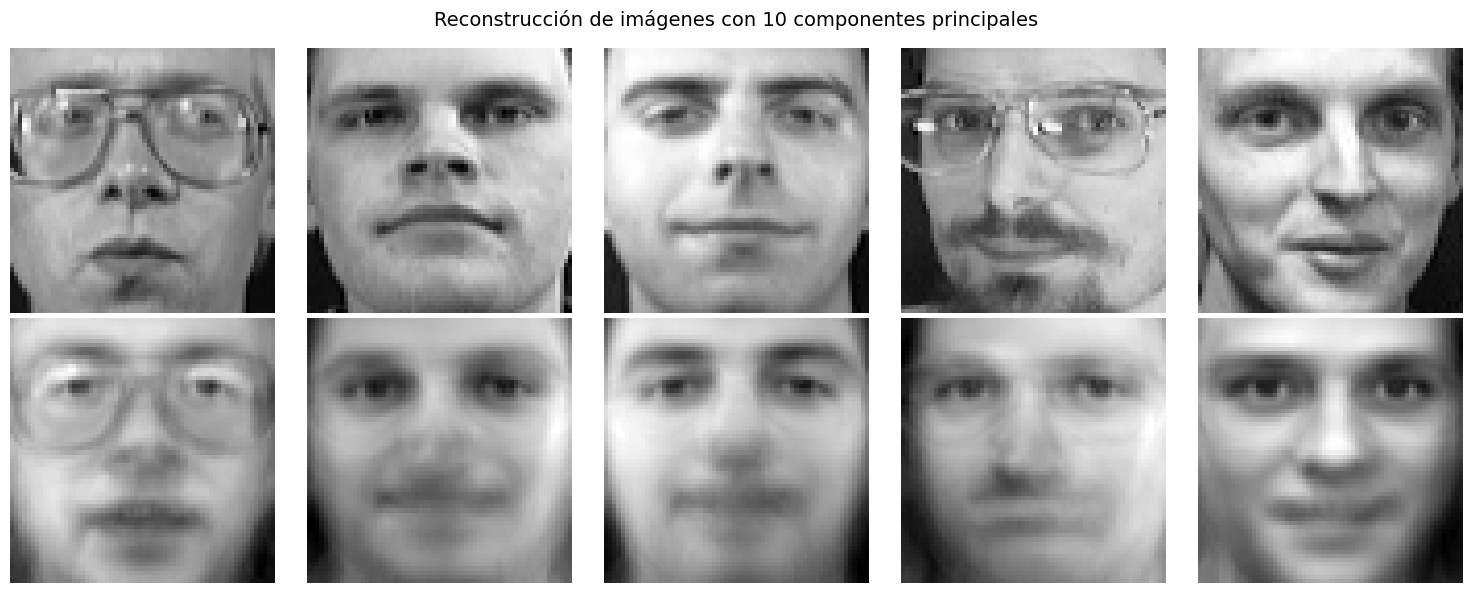

In [59]:
visualizar_reconstruccion(
    X_train,
    X_test,
    n_componentes=10,
    n_caras=5
)

#### Extra 2.3 Reconstrucción con 20 componentes

Aumentamos el número de componentes principales a 20 para comprobar cómo mejora la reconstrucción de las imágenes al conservar una mayor cantidad de información.

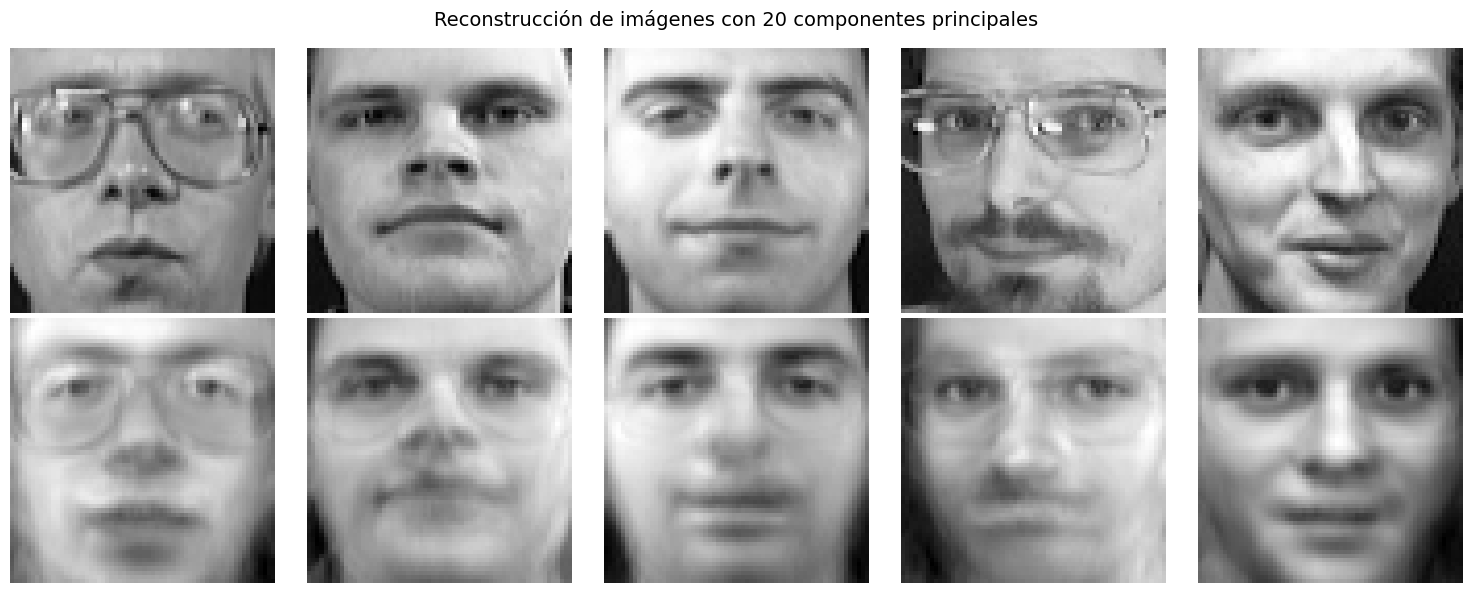

In [60]:
visualizar_reconstruccion(
    X_train,
    X_test,
    n_componentes=20,
    n_caras=5
)

#### Extra 2.4 Reconstrucción con 30 componentes

Probamos la reconstrucción con 30 componentes principales para observar si el aumento de información conservada permite recuperar con mayor claridad los rasgos de las imágenes originales.

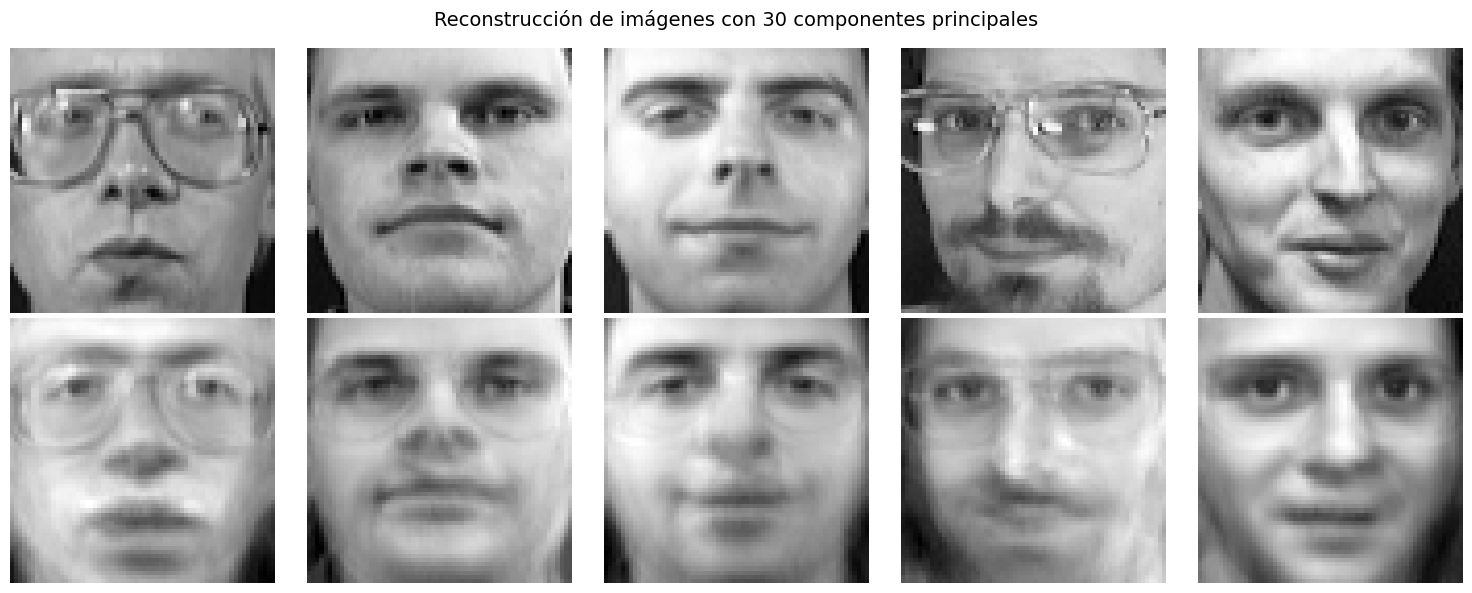

In [61]:
visualizar_reconstruccion(
    X_train,
    X_test,
    n_componentes=30,
    n_caras=5
)

#### Extra 2.5 Reconstrucción con 40 componentes

Aumentamos a 40 componentes principales para observar la calidad de las imágenes reconstruidas al acercarnos al límite superior del rango de compresión utilizado anteriormente.

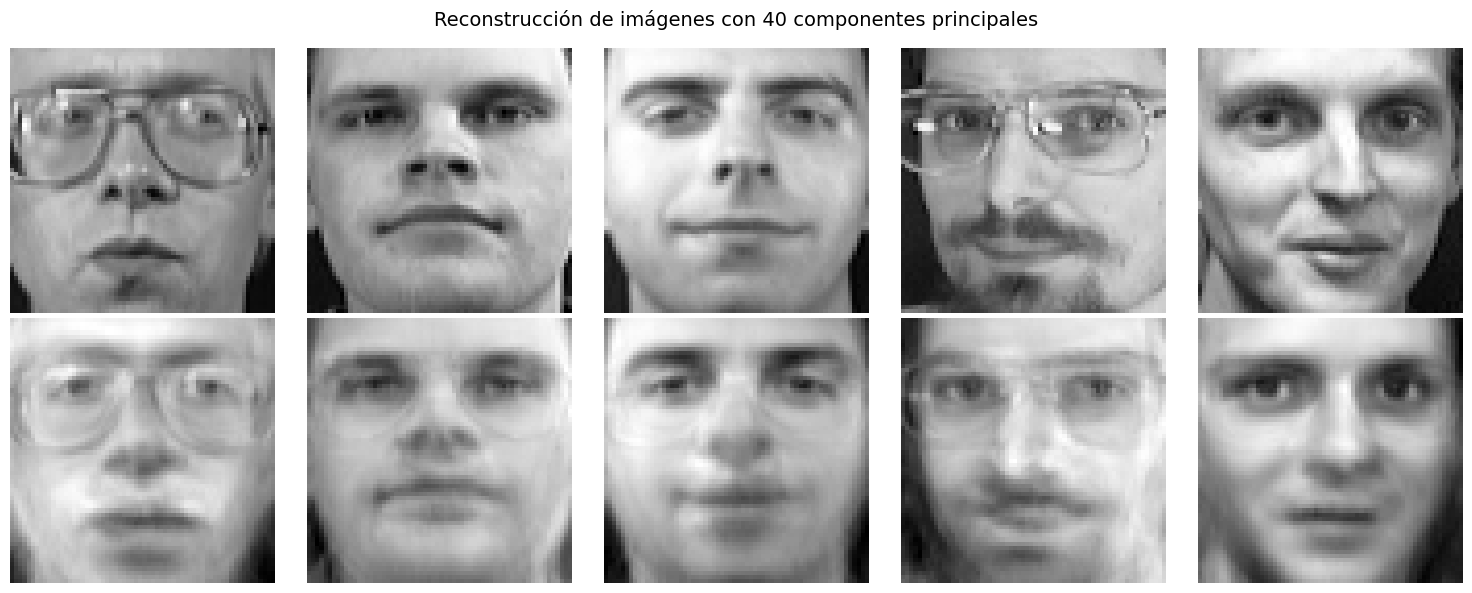

In [62]:
visualizar_reconstruccion(
    X_train,
    X_test,
    n_componentes=40,
    n_caras=5
)

#### Extra 2.6 Reconstrucción con 150 componentes

Aumentamos el número de componentes principales a 150 para comprobar cómo se aproxima la imagen reconstruida a la original cuando PCA conserva una cantidad mucho mayor de información.

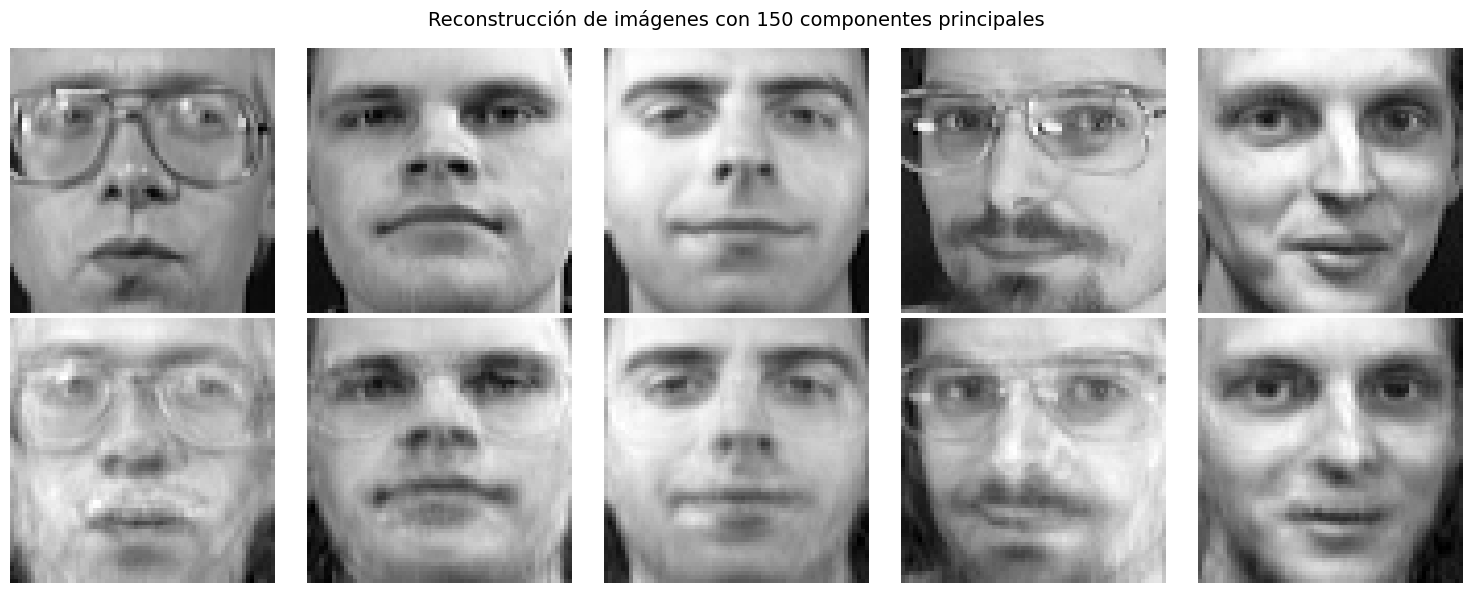

In [63]:
visualizar_reconstruccion(
    X_train,
    X_test,
    n_componentes=150,
    n_caras=5
)

#### Extra 2.7 Reconstrucción con 320 componentes

Finalmente, utilizamos 320 componentes principales, el máximo disponible en el conjunto de entrenamiento, para comprobar hasta qué punto las imágenes reconstruidas se aproximan a las imágenes originales.

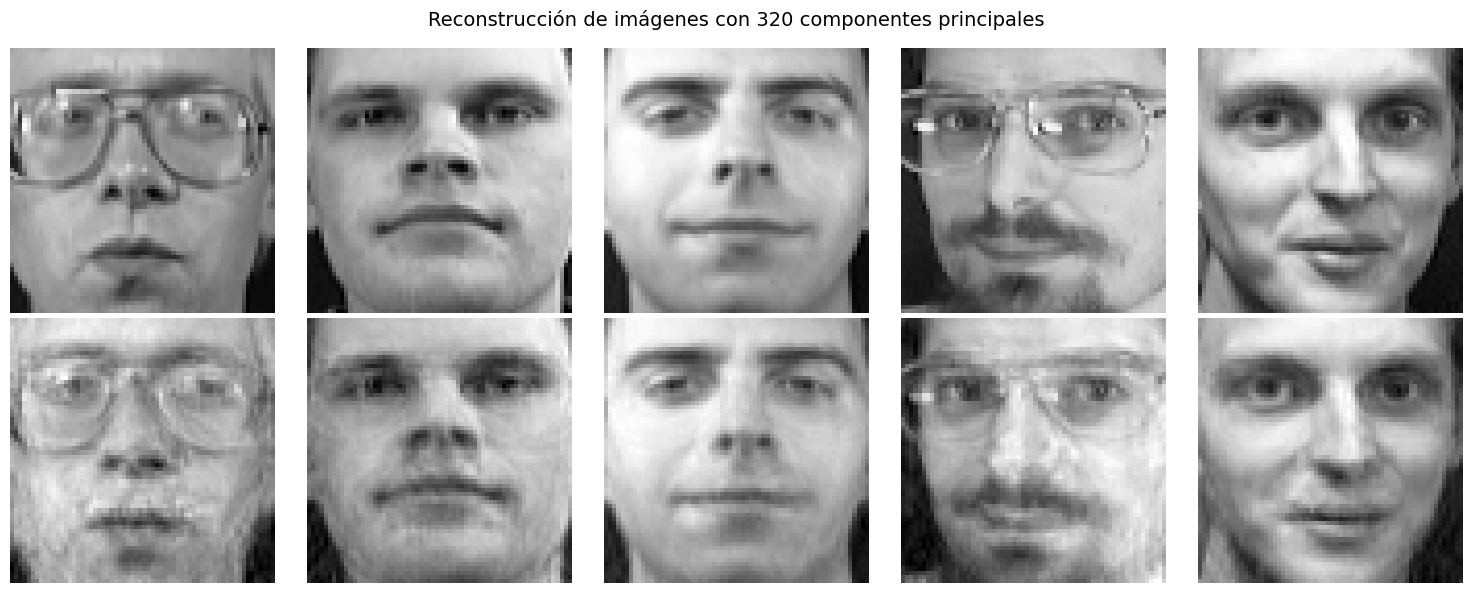

In [68]:
visualizar_reconstruccion(
    X_train,
    X_test,
    n_componentes=320,
    n_caras=5
)

#### Conclusión del Extra 2

La comparación visual muestra claramente el efecto del número de componentes principales sobre la reconstrucción de las imágenes.

Con 5 y 10 componentes se conserva la estructura general de las caras, pero se pierde una gran cantidad de detalle. Al aumentar a 20, 30 y 40 componentes, los rasgos faciales se vuelven progresivamente más reconocibles, aunque las imágenes todavía presentan cierto suavizado.

Con 150 componentes la reconstrucción mejora considerablemente y con 320 componentes las imágenes reconstruidas se aproximan mucho más a las originales, conservando detalles como gafas, barba y contornos faciales.

Esto permite observar el compromiso que introduce PCA entre compresión y conservación de información: un menor número de componentes proporciona una mayor compresión, mientras que aumentar el número de componentes mejora la calidad de la reconstrucción.